# **PROJECT: Market Basket + Bundle Profit Analysis**
Dataset: Datos.csv

Our Client it's a construction materials a company with over 30 years of experience in the Mexican heavy construction materials market. Its product range extends from steel (rebar, wire rod, and wire) to cement and concrete.
They hired us as external consultants to answer a specific question: which products can be bundled in a way that customers are willing to pay for?

The project's objective was to provide stakeholders with a deeper understanding of customer behavior and product interactions, and to develop viable strategies capable of strengthening profit margins.
### Goal: rules (A->B) + expected incremental profit with discount

In [3]:

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [4]:
df = pd.read_csv("/content/drive/MyDrive/Proyectos/Datos.csv")

# Cleaning and Standarization

In [5]:
def canon_id(x):
    return (
        str(x)
        .strip()
        .lower()
        .replace("{", "")
        .replace("}", "")
        .replace('"', "")
        .replace("'", "")
    )

df["product_id"] = df["product_id"].apply(canon_id)

df["product_name"] = (
    df["product_name"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip())

## Anonymization of Sensitive Data

This a very important first step thus the infomration that handling is sensitive, so we will following these next framework for Anonymization of Sensitive Data.

1. Pseudonymize
2. Id Generalization
3. Add random noise




In [26]:
sale_id_mapping = {id: f'SALE_{i+1:05d}' for i, id in enumerate(df['sale_id'].unique())}
product_id_mapping = {id: f'PROD_{i+1:04d}' for i, id in enumerate(df['product_id'].unique())}

df_anon = df.copy()
df_anon['sale_id'] = df_anon['sale_id'].map(sale_id_mapping)
df_anon['product_id'] = df_anon['product_id'].map(product_id_mapping)


# Get unique product names and shuffle them
original_product_names = df_anon['product_name'].unique()
shuffled_product_names = original_product_names.copy()
np.random.shuffle(shuffled_product_names)
name_shuffling_map = dict(zip(original_product_names, shuffled_product_names))

df_anon['product_name_anon'] = df_anon['product_name'].map(name_shuffling_map)

numerical_cols = [
    'product_price_catalog', 'product_cost_price', 'product_price',
    'price_used', 'cost_used', 'unit_profit_used'
]

noise_factor = 0.02 # 2% noise

for col in numerical_cols:
    if col in df_anon.columns:

        noise = df_anon[col] * (np.random.uniform(-noise_factor, noise_factor, df_anon.shape[0]))
        df_anon[col] = df_anon[col] + noise
        # Ensure non-negative values
        df_anon[col] = df_anon[col].apply(lambda x: max(0, x))

print("Anonymized DataFrame head:")
display(df_anon.head())

print("\nOriginal vs Anonymized Product IDs:")
print(df[['product_id', 'product_name']].head())
print(df_anon[['product_id', 'product_name_anon']].head())

df = df_anon

Anonymized DataFrame head:


,sale_id,customerid,sale_date,subtotal,total,product_id,product_name,product_price,product_quantity,product_price_catalog,product_cost_price,product_category,unit_gross_profit,unit_gross_margin,price_used,cost_used,unit_profit_used,product_name_anon
0,SALE_00001,f6724545-2d7c-4def-9af2-ab768aad727b,2026-02-28,6034.49,7000.01,PROD_0001,ARENA #5 METRO CUBICO,1206.723709,-3557972,0.000000,0.000000,NaN,NaN,NaN,1190.756176,0.000000,0.00000,MALLA ELECTROSOLDADA 661010 ROLLO
1,SALE_00001,f6724545-2d7c-4def-9af2-ab768aad727b,2026-02-28,6034.49,7000.01,PROD_0002,ARENA #5 1/2 METRO CUBICO,636.578207,-3557972,0.000000,0.000000,NaN,NaN,NaN,634.000409,0.000000,0.00000,ARENA #5 METRO CUBICO TOSTON
2,SALE_00001,f6724545-2d7c-4def-9af2-ab768aad727b,2026-02-28,6034.49,7000.01,PROD_0003,CEMENTO GRIS MONTERREY EXTRA 50KG,245.572924,-17971,245.836367,219.221731,CEMENTO,30.17,0.122797,241.685098,216.137650,30.32357,VARILLA 3/8 PIEZA FERRETERO
3,SALE_00001,f6724545-2d7c-4def-9af2-ab768aad727b,2026-02-28,6034.49,7000.01,PROD_0004,CARGO POR ENTREGA 300 ZONA,260.267781,-1044,259.523402,149.656763,SERVICIO,108.62,0.419998,255.289440,148.057137,110.50470,RENTA EXCAVADORA
4,SALE_00002,3e4561f8-20d1-4f29-acef-5c901d8271e5,2026-02-28,603.45,700.00,PROD_0005,MIXTO MEDIO METRO CUBICO FERRETERO,613.470945,-6612376,0.000000,0.000000,NaN,NaN,NaN,611.296951,0.000000,0.00000,TIERRA AMARILLA



Original vs Anonymized Product IDs:
                             product_id                        product_name
0  a9093702-c028-4b57-9831-5893575a28e3               ARENA #5 METRO CUBICO
1  fec5a840-782e-467e-894c-ee075fe1c628           ARENA #5 1/2 METRO CUBICO
2  4fc56492-ce5a-4f2f-a88a-8911b4fc07b9   CEMENTO GRIS MONTERREY EXTRA 50KG
3  d4e264bc-47f8-4725-98f6-e3b32208441a          CARGO POR ENTREGA 300 ZONA
4  e7242b7d-1a36-4593-940d-4f3a44bd0c8b  MIXTO MEDIO METRO CUBICO FERRETERO
  product_id                  product_name_anon
0  PROD_0001  MALLA ELECTROSOLDADA 661010 ROLLO
1  PROD_0002       ARENA #5 METRO CUBICO TOSTON
2  PROD_0003        VARILLA 3/8 PIEZA FERRETERO
3  PROD_0004                   RENTA EXCAVADORA
4  PROD_0005                    TIERRA AMARILLA


In [7]:
display(df_anon.columns)

Index(['sale_id', 'customerid', 'sale_date', 'subtotal', 'total', 'product_id',
       'product_name', 'product_price', 'product_quantity',
       'product_price_catalog', 'product_cost_price', 'product_category',
       'unit_gross_profit', 'unit_gross_margin', 'product_name_anon'],
      dtype='object')

### Verification of Anonymization

Let's verify that the key identifiers and numerical values have been altered. We can compare descriptive statistics to see that the overall distribution is maintained, but individual values are changed.

In [28]:
df["product_price_catalog"] = pd.to_numeric(df["product_price_catalog"], errors="coerce")
df["product_cost_price"] = pd.to_numeric(df["product_cost_price"], errors="coerce")
df["product_price"] = pd.to_numeric(df["product_price"], errors="coerce")

# profitability:
df["price_used"] = df["product_price_catalog"].fillna(df["product_price"])
df["cost_used"] = df["product_cost_price"]

# Unit profit
df["unit_profit_used"] = df["price_used"] - df["cost_used"]

In [30]:
print("Descriptive statistics for original 'unit_profit_used':")
display(df['unit_profit_used'].describe())

print("\nDescriptive statistics for anonymized 'unit_profit_used':")
display(df_anon['unit_profit_used'].describe())

# Check a few specific original vs. anonymized values (careful not to reveal too much)
print("\nSample of original vs. anonymized price_used:")
display(pd.DataFrame({
    'original_price_used': df['price_used'].head(),
    'anonymized_price_used': df_anon['price_used'].head()
}))

Descriptive statistics for original 'unit_profit_used':


,unit_profit_used
count,36448.000000
mean,45.795613
std,293.527186
min,0.000000
25%,0.000000
50%,7.876648
75%,40.817554
max,19476.213643



Descriptive statistics for anonymized 'unit_profit_used':


,unit_profit_used
count,36448.000000
mean,45.795613
std,293.527186
min,0.000000
25%,0.000000
50%,7.876648
75%,40.817554
max,19476.213643



Sample of original vs. anonymized price_used:


,original_price_used,anonymized_price_used
0,0.000000,0.000000
1,0.000000,0.000000
2,245.836367,245.836367
3,259.523402,259.523402
4,0.000000,0.000000


# DataSet Exploration

In [31]:
df["product_price_catalog"] = pd.to_numeric(df["product_price_catalog"], errors="coerce")
df["product_cost_price"] = pd.to_numeric(df["product_cost_price"], errors="coerce")
df["product_price"] = pd.to_numeric(df["product_price"], errors="coerce")

# Official price used for profitability:
df["price_used"] = df["product_price_catalog"].fillna(df["product_price"])
df["cost_used"] = df["product_cost_price"]

# Unit profit with chosen price/cost
df["unit_profit_used"] = df["price_used"] - df["cost_used"]

In [32]:
#DataSet Atributes
n_sales = df["sale_id"].nunique()
n_items = df["product_id"].nunique()
avg_items_per_sale = len(df) / n_sales if n_sales else float("nan")

print("Rows:", df.shape)
print("Unique sales:", n_sales)
print("Unique products:", n_items)
print("Avg items per sale:", round(avg_items_per_sale, 2))

Rows: (36448, 18)
Unique sales: 14780
Unique products: 139
Avg items per sale: 2.47


A Basket analysis is very usefull in this type of situations it uncovers patterns in customer purchasing behavior, identifying products frequently bought together. By analyzing these combinations, businesses can optimize product placement, enhance cross-selling/up-selling strategies, and improve marketing efforts to increase revenue and customer satisfaction

# Basket Construction

In [33]:
basket = df.groupby("sale_id")["product_id"].apply(list)  #Basket creation

te = TransactionEncoder()  #apriori needs of this type of format.
basket_df = pd.DataFrame(te.fit(basket).transform(basket), columns=te.columns_)

print("Basket matrix shape:", basket_df.shape)

#------------------------------#

MIN_SUPPORT = 0.02   #2% of the unique sales ... 256 proxy
MAX_LEN = 3          # pairs + triplets

frequent_itemsets = apriori(
    basket_df,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=MAX_LEN
)
frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)

print("Frequent itemsets:", frequent_itemsets.shape)


Basket matrix shape: (14780, 139)
Frequent itemsets: (55, 3)


In [34]:
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules = rules[(rules["confidence"] >= 0.30) & (rules["lift"] >= 1.20)].copy()

print("Rules:", rules.shape)


rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules = rules[(rules["confidence"] >= 0.30) & (rules["lift"] >= 1.20)].copy()

print("Rules:", rules.shape)



Rules: (19, 14)
Rules: (19, 14)


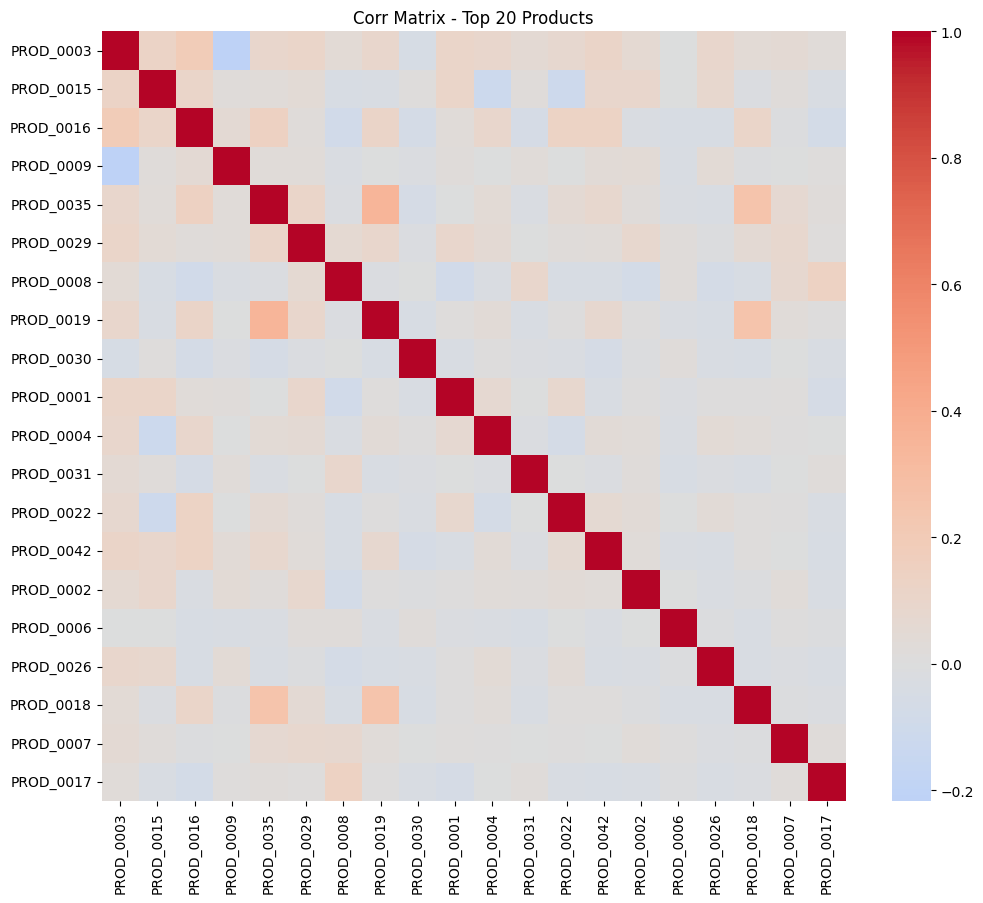

In [49]:
# We will create the cormatrix visualization to confirm the existance of correlation between our products
#for strenghtening of basket model

basket = df.groupby("sale_id")["product_id"].apply(list)

te = TransactionEncoder()
basket_df = pd.DataFrame(te.fit(basket).transform(basket), columns=te.columns_)

corr_matrix = basket_df.corr()

top_products = df["product_id"].value_counts().head(20).index

corr_top = basket_df[top_products].corr()

plt.figure(figsize=(12,10))
sns.heatmap(
    corr_top,
    cmap="coolwarm",
    center=0,
    annot=False
)
plt.title("Corr Matrix - Top 20 Products")
plt.savefig("heatmap1.png", dpi=150, bbox_inches="tight")

plt.show()



In [36]:
rules_1to1 = rules[
    (rules["antecedents"].apply(len) == 1) &
    (rules["consequents"].apply(len) == 1)
].copy()

rules_1to1["antecedent_id"] = rules_1to1["antecedents"].apply(lambda s: list(s)[0])
rules_1to1["consequent_id"] = rules_1to1["consequents"].apply(lambda s: list(s)[0])

print("Rules 1→1:", rules_1to1.shape)

Rules 1→1: (16, 16)


In [37]:
id_to_name = (
    df[["product_id", "product_name"]]
    .drop_duplicates()
    .set_index("product_id")["product_name"]
    .to_dict()
)

rules_1to1["antecedent_name"] = rules_1to1["antecedent_id"].map(lambda x: id_to_name.get(x, x))
rules_1to1["consequent_name"] = rules_1to1["consequent_id"].map(lambda x: id_to_name.get(x, x))


# Business Metrics

In [38]:
product_metrics = (
    df.groupby("product_id")
      .agg(
          avg_price=("price_used", "mean"),
          avg_cost=("cost_used", "mean")
      )
      .reset_index()
)

rules_1to1 = rules_1to1.merge(
    product_metrics,
    left_on="consequent_id",
    right_on="product_id",
    how="left"
)

# Debug: check missing economics after merge
print("\nMissing after merge (avg_price/avg_cost):")
print(rules_1to1[["avg_price", "avg_cost"]].isna().mean())



Missing after merge (avg_price/avg_cost):
avg_price    0.0
avg_cost     0.0
dtype: float64


In [39]:
DISCOUNT = 0.05  # Discount Simulation


rules_1to1["support_A"] = rules_1to1["support"] / rules_1to1["confidence"]

rules_1to1["expected_new_sales"] = (
    rules_1to1["support_A"] * n_sales * (1 - rules_1to1["confidence"])
).round(0)

# profit per unit with discount
rules_1to1["discounted_profit_per_unit"] = (rules_1to1["avg_price"] * (1 - DISCOUNT)) - rules_1to1["avg_cost"] # profit per unit with discount


rules_1to1["incremental_profit"] = rules_1to1["expected_new_sales"] * rules_1to1["discounted_profit_per_unit"]  # incremental profit


#TOP CANDIDATES

In [40]:

cols = [
    "antecedent_name", "consequent_name",
    "support", "confidence", "lift",
    "expected_new_sales",
    "avg_price", "avg_cost",
    "discounted_profit_per_unit",
    "incremental_profit"]
top_profit = rules_1to1.sort_values("incremental_profit", ascending=False)[cols].head(20)
print("\n=== TOP 20 by incremental_profit (5% discount on consequent) ===")
print(top_profit.to_string(index=False))



=== TOP 20 by incremental_profit (5% discount on consequent) ===
             antecedent_name                   consequent_name  support  confidence     lift  expected_new_sales  avg_price   avg_cost  discounted_profit_per_unit  incremental_profit
       ARENA #5 METRO CUBICO      CARGO POR ENTREGA 200 ZONA 1 0.023816    0.305291 1.813583               801.0 172.405547 100.039660                   63.745610        51060.233292
CARGO POR ENTREGA 200 ZONA 1 CEMENTO GRIS MONTERREY EXTRA 50KG 0.065832    0.391077 1.449015              1515.0 245.626861 215.517527                   17.827991        27009.406416
           VARILLA 3/8 PIEZA CEMENTO GRIS MONTERREY EXTRA 50KG 0.043099    0.387942 1.437397              1005.0 245.626861 215.517527                   17.827991        17917.130989
              ARENA #5 BULTO CEMENTO GRIS MONTERREY EXTRA 50KG 0.031191    0.326950 1.211413               949.0 245.626861 215.517527                   17.827991        16918.763491
                   

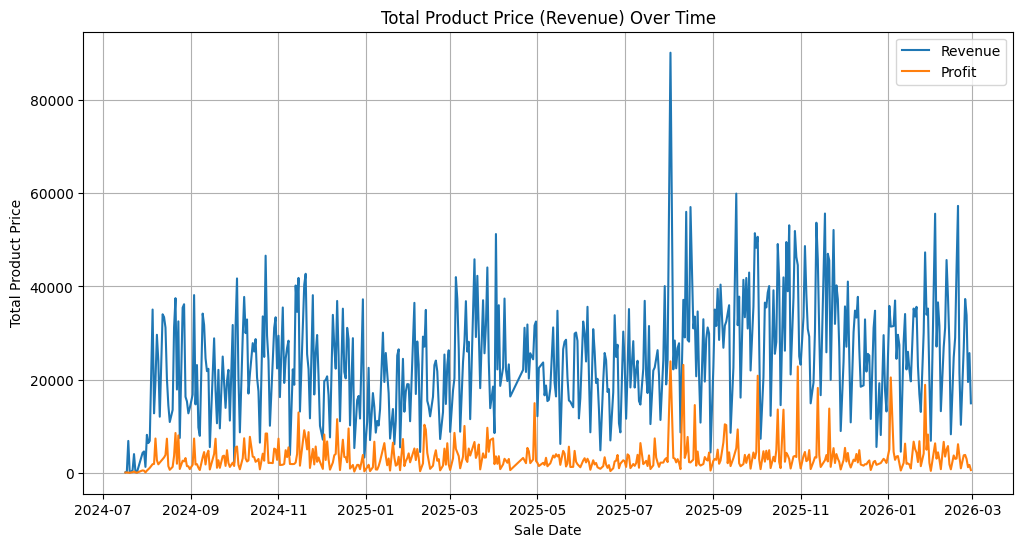

<Figure size 640x480 with 0 Axes>

In [41]:
# Convert 'sale_date' to datetime objects for proper time series plotting
df["sale_date"] = pd.to_datetime(df["sale_date"])

revenue = df.groupby("sale_date")["product_price"].sum().reset_index()
profit = df.groupby("sale_date")["unit_gross_profit"].sum().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(revenue["sale_date"], revenue["product_price"])
plt.plot(profit["sale_date"], profit["unit_gross_profit"])

plt.title("Total Product Price (Revenue) Over Time")
plt.xlabel("Sale Date")
plt.ylabel("Total Product Price")
plt.legend(["Revenue", "Profit"])
plt.grid(True)
plt.show()
plt.savefig("revenue_vs_profit.png", dpi=150, bbox_inches="tight")

It can be see a certain Seasonality between Revenue and Profit

In [42]:
rules_1to1.to_csv("rules_1to1_with_profit.csv", index=False)
frequent_itemsets.to_csv("frequent_itemsets.csv", index=False)

print("\nSaved: rules_1to1_with_profit.csv, frequent_itemsets.csv")


Saved: rules_1to1_with_profit.csv, frequent_itemsets.csv


## Aggregate Incremental Profit


In [43]:
aggregated_incremental_profit = rules_1to1.groupby('consequent_id')['incremental_profit'].sum().reset_index()
aggregated_incremental_profit.rename(columns={'incremental_profit': 'total_incremental_profit'}, inplace=True)
print(aggregated_incremental_profit.head())

  consequent_id  total_incremental_profit
0     PROD_0003             161521.598767
1     PROD_0015              51060.233292
2     PROD_0019               3276.091698
3     PROD_0035                  0.000000


Now that the total incremental profit for each consequent product has been calculated, a  merge will be used  into the `product_summary` DataFrame. This will allow for the creation of a `future_profit` column, which combines the existing `total_profit` with the potential incremental profit.



In [44]:
product_summary = df.groupby('product_id').agg(
    total_profit=('unit_profit_used', 'sum'),
    product_name=('product_name', 'first')
).reset_index()

product_summary = product_summary.merge(aggregated_incremental_profit,
                                    left_on='product_id',
                                        right_on='consequent_id',
                                        how='left')

product_summary['total_incremental_profit'] = product_summary['total_incremental_profit'].fillna(0)

product_summary['future_profit'] = product_summary['total_profit'] + product_summary['total_incremental_profit']

print("Product Summary with Future Profit (head):")
print(product_summary.head())

Product Summary with Future Profit (head):
  product_id   total_profit                        product_name consequent_id  \
0  PROD_0001       0.000000               ARENA #5 METRO CUBICO           NaN   
1  PROD_0002       0.000000           ARENA #5 1/2 METRO CUBICO           NaN   
2  PROD_0003  120106.133674   CEMENTO GRIS MONTERREY EXTRA 50KG     PROD_0003   
3  PROD_0004   98671.843273          CARGO POR ENTREGA 300 ZONA           NaN   
4  PROD_0005       0.000000  MIXTO MEDIO METRO CUBICO FERRETERO           NaN   

   total_incremental_profit  future_profit  
0                  0.000000       0.000000  
1                  0.000000       0.000000  
2             161521.598767  281627.732442  
3                  0.000000   98671.843273  
4                  0.000000       0.000000  


In [45]:
top_products_to_plot = product_summary.sort_values(by='future_profit', ascending=False).head(10)

print("Top 10 Products by Future Profit:")
print(top_products_to_plot[['product_name', 'total_profit', 'total_incremental_profit', 'future_profit']].to_string(index=False))

Top 10 Products by Future Profit:
                     product_name  total_profit  total_incremental_profit  future_profit
                CARGO POR ENTREGA 413752.287440                  0.000000  413752.287440
CEMENTO GRIS MONTERREY EXTRA 50KG 120106.133674             161521.598767  281627.732442
         SUMINISTRO DE MATERIALES 253735.847433                  0.000000  253735.847433
     CARGO POR ENTREGA 200 ZONA 1 180046.326735              51060.233292  231106.560027
       CARGO POR ENTREGA 300 ZONA  98671.843273                  0.000000   98671.843273
                   CEMENTO APASCO  79906.244315                  0.000000   79906.244315
               ARENA CRIBADA 40KG  66529.480526                  0.000000   66529.480526
           TRASLADO DE MAQUINARIA  57848.578685                  0.000000   57848.578685
     CARGO POR ENTREGA 250 ZONA 2  56303.124601                  0.000000   56303.124601
                 YESO MAXIMO 40KG  38339.670141                  0.000000   

# Visualization Total profit Vs Future Profit

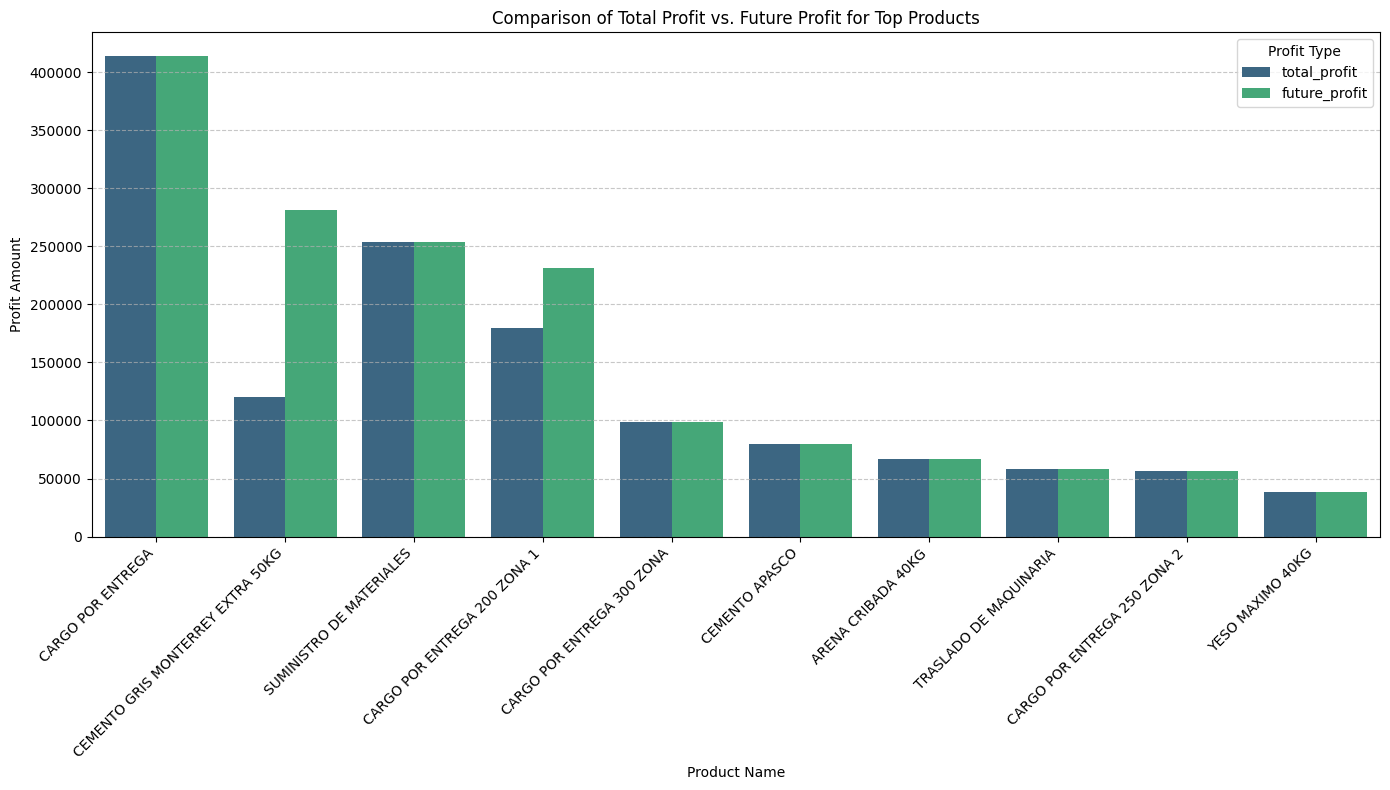

<Figure size 640x480 with 0 Axes>

In [46]:

# Melt the DataFrame for easier plotting
plot_data = top_products_to_plot.melt(id_vars=['product_name'],
                                      value_vars=['total_profit', 'future_profit'],
                                      var_name='Profit Type',
                                      value_name='Profit Amount')

plt.figure(figsize=(14, 8))
sns.barplot(x='product_name', y='Profit Amount', hue='Profit Type', data=plot_data, palette='viridis')
plt.title('Comparison of Total Profit vs. Future Profit for Top Products')
plt.xlabel('Product Name')
plt.ylabel('Profit Amount')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Profit Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
plt.savefig("future_profit.png", dpi=150, bbox_inches="tight")

This analysis confirms that cement acts as the anchor product within the portfolio, driving both transaction frequency and cross-product associations. Freight-related items also represent a critical profitability lever, particularly in bundle scenarios.

The bundle simulation suggests that targeted discounting strategies — especially when anchored to cement purchases — could unlock meaningful incremental profit without structurally reducing margins.

However, before operationalizing these recommendations, it is necessary to validate missing economic values (NaNs) in the dataset to ensure that the absence of projected future profit in certain high-lift products is not due to data gaps or pipeline inconsistencies in GCP.

Overall, the evidence points to clear, data-backed opportunities to strengthen margins through intelligent cross-selling, rather than volume-based discounting.